


# Detección y clasificación de figuras


- Momentos de Hu con `cv2.HuMoments`.
- Aprox del conteo `cv2.approxPolyDP` para contar vertices

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Cargar la imagen

Cargamos `image.png` 

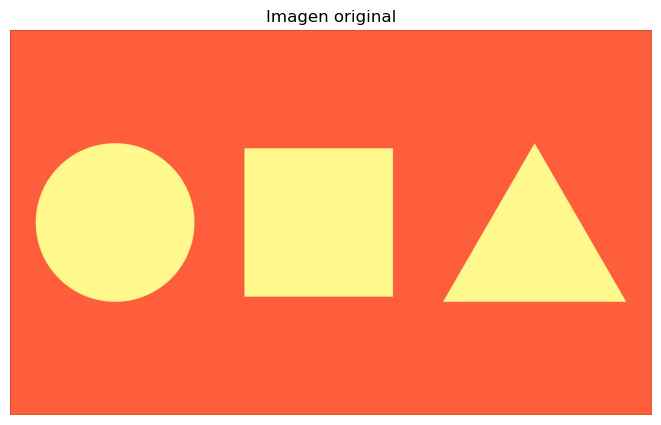

In [2]:
img = cv2.imread('image.png')

if img is None:
    raise FileNotFoundError('No se encontro image.png tilin insano')

plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')
plt.show()

## 2. Detectar contornos con bordes (Canny)

usamos **detección de bordes con `cv2.Canny`**. 

Después *dilatamos* los bordes para cerrarlos y buscamos los contornos externos.

Figuras detectadas: 3


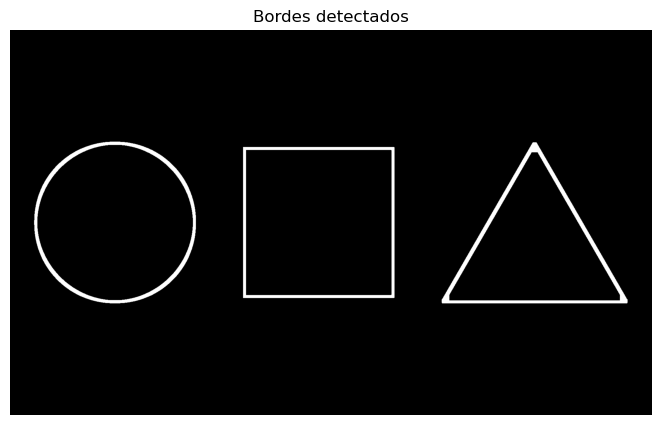

In [3]:
# Esc grises y desenf r
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# det b
edges = cv2.Canny(blur, 50, 150)

# cerrar
edges = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=2)
edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=2)

# Contornos externos
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filt ruido
area_min = 0.002 * img.shape[0] * img.shape[1]
contours = [c for c in contours if cv2.contourArea(c) > area_min]

print(f'Figuras detectadas: {len(contours)}')

plt.figure(figsize=(9, 5))
plt.imshow(edges, cmap='gray')
plt.title('Bordes detectados')
plt.axis('off')
plt.show()

## 3. Clasificar por número de vértices

Usamos `cv2.approxPolyDP` para aproximar el contorno a un polígono y contar sus vértices:

- **3** triangulo
- **4** cuadrado 
- **muchos** circulo

In [4]:
def clasificar(contorno):
    perimetro = cv2.arcLength(contorno, True)
    approx = cv2.approxPolyDP(contorno, 0.04 * perimetro, True)
    vertices = len(approx)

    if vertices == 3:
        return 'Triangulo', approx
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx) 
        ratio = w / float(h)
        if 0.90 <= ratio <= 1.10:
            return 'Cuadrado', approx
        else:
            return 'Rectangulo', approx
    else:
        return 'Circulo', approx

## 4. Momentos de Hu y resultado

Para cada figura calculamos los momentos de Hu y dibujamos su clasificacinn sobre la imagen

Figura 1: Cuadrado  (vertices = 4)
  Momentos de Hu:
    Hu[0] = 1.6667e-01
    Hu[1] = 1.3626e-07
    Hu[2] = 1.4875e-12
    Hu[3] = 1.6333e-13
    Hu[4] = -8.0502e-26
    Hu[5] = 6.0290e-17
    Hu[6] = -1.1782e-34

Figura 2: Triangulo  (vertices = 3)
  Momentos de Hu:
    Hu[0] = 1.9218e-01
    Hu[1] = 2.2110e-08
    Hu[2] = 4.5137e-03
    Hu[3] = 2.8441e-09
    Hu[4] = -1.0186e-14
    Hu[5] = -4.2198e-13
    Hu[6] = -2.8550e-16

Figura 3: Circulo  (vertices = 8)
  Momentos de Hu:
    Hu[0] = 1.5916e-01
    Hu[1] = 3.6370e-11
    Hu[2] = 5.5816e-11
    Hu[3] = 2.7087e-15
    Hu[4] = -9.8689e-28
    Hu[5] = 1.4523e-20
    Hu[6] = 3.6788e-28



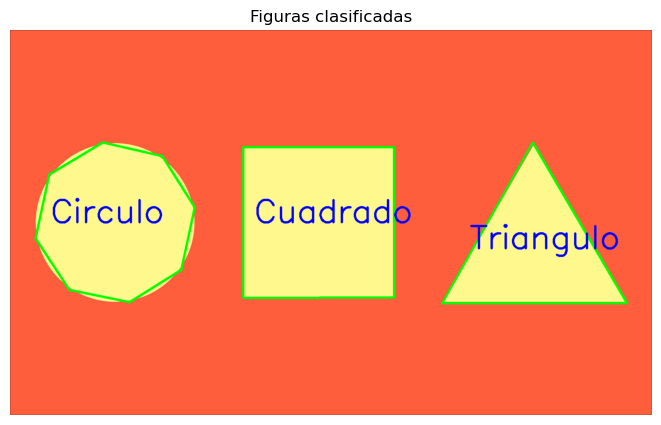

In [5]:
salida = img.copy()

esc = max(img.shape[:2]) / 600.0

for i, c in enumerate(contours):
    nombre, approx = clasificar(c)

    # Momentos y momentos de Hu
    M = cv2.moments(c)
    hu = cv2.HuMoments(M).flatten()

    # Centro de la figura (para ubicar el texto)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = approx[0][0]

    # Dibujamos contorno aproximado y la etiqueta
    cv2.drawContours(salida, [approx], -1, (0, 255, 0), int(2 * esc))
    cv2.putText(salida, nombre, (cx - int(60 * esc), cy),
                cv2.FONT_HERSHEY_SIMPLEX, esc, (255, 0, 0), int(2 * esc))

    print(f'Figura {i + 1}: {nombre}  (vertices = {len(approx)})')
    print('  Momentos de Hu:')
    for j, h in enumerate(hu):
        print(f'    Hu[{j}] = {h:.4e}')
    print()

plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
plt.title('Figuras clasificadas')
plt.axis('off')
plt.show()